# **Классификация музыкальных рецензий: определение тональности отзыва по тексту отзыва.**
Вариант 3 (Классификация текстов с классическими ML моделями).


**Выбор датасета и обоснование**

По заданию нужен датасет для бинарной классификации текстов.  Я люблю музыку, поэтому решила взять что-то связаное с ней. Рецензии Pitchfork - это готовый, реальный, профессионально написанный текст, у каждой рецензии есть числовая оценка критика (0-10), из которой можно получить целевую метку класса без ручной разметки. Метка класса будет сделана по медиане, а не по фиксированному порогу, потому что оценки Pitchfork сильно смещены в плюс (средняя ≈ 7.0, большинство рецензий лежат в диапазоне 6.4-7.8). Если использовать фиксированный порог (например, "хорошо" ≥ 7, "плохо" < 5), класс "плохих" отзывов получился бы маленьким, и сильный дисбаланс классов усложнил бы обучение и интерпретацию метрик. Разметка по медиане всего исходного датасета (получилось 7.2) решит эту проблему: она автоматически делит данные ровно пополам.

**Часть 1. EDA и Feature Engineering**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 150)

%matplotlib inline

In [2]:
file_id = '167NseEMdesHNyM2BUNatTyMozVis07ID'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)
df.head()

,reviewid,artist,title,genre,pub_year,score,label,content
0,10699,gang gang dance,rawwar ep,experimental,2007,7.4,1,\r\n Gang Gang Dance's 2006 CMJ performance at Webster Hall remains an unexpectedly transcendent moment. I'd seen the quartet a dozen times bef...
1,13868,strong arm steady,in search of stoney jackson,"pop/r&b, rap",2010,7.1,0,"Finding patterns in Madlib's rambling yet brilliant production work can be difficult, but on his new In Search of Stoney Jackson album, he doesn't..."
2,7864,various artists,groove ost,NaN,2000,5.7,0,"Funny, I'm not at a rave, and I'm certainly not on e, yet I'm grinding my\n teeth. Maybe it's the music.\n \n Sony Pictures' attempt to ..."
3,17035,menomena,moms,"experimental, rock",2012,8.0,1,"Editor's Note: The lead of this review has been changed, as the original text contained a passage similar to one found in the Willamette Week inte..."
4,22467,kate bush,before the dawn,pop/r&b,2016,8.5,1,"Kate Bush always exploited technological advancement. In 1979, from just coathangers and Blu-Tack, the trailblazing British pop auteur pioneered t..."


In [3]:
df.info()

print()
print("Пропуски по колонкам:")
print(df.isna().sum())

print()
print("Полные дубликаты строк:", df.duplicated().sum())
print("Дубликаты по reviewid:", df.duplicated(subset=['reviewid']).sum())
print("Дубликаты по тексту рецензии (content):", df.duplicated(subset=['content']).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   reviewid  5000 non-null   int64  
 1   artist    5000 non-null   object 
 2   title     5000 non-null   object 
 3   genre     4348 non-null   object 
 4   pub_year  5000 non-null   int64  
 5   score     5000 non-null   float64
 6   label     5000 non-null   int64  
 7   content   5000 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 312.6+ KB

Пропуски по колонкам:
reviewid      0
artist        0
title         0
genre       652
pub_year      0
score         0
label         0
content       0
dtype: int64

Полные дубликаты строк: 0
Дубликаты по reviewid: 0
Дубликаты по тексту рецензии (content): 0


label
0    2500
1    2500
Name: count, dtype: int64


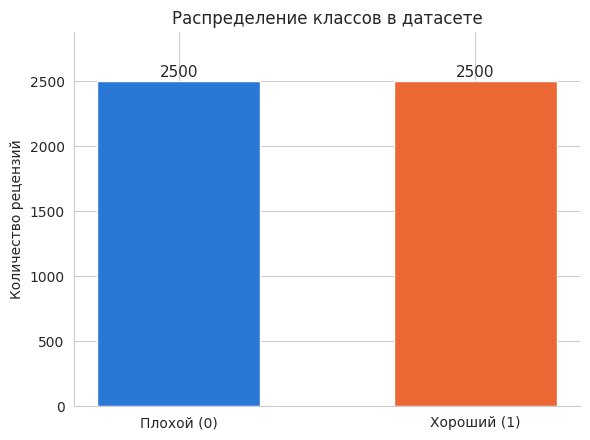

In [4]:
counts = df['label'].value_counts().sort_index()
print(counts)

colors = ['#2a78d6', '#eb6834']

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(['Плохой (0)', 'Хороший (1)'], counts.values, color=colors, width=0.55)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30, str(val), ha='center', fontsize=11)

ax.set_title('Распределение классов в датасете')
ax.set_ylabel('Количество рецензий')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

count    5000.00000
mean      645.80160
std       227.96038
min        84.00000
25%       497.00000
50%       599.00000
75%       742.00000
max      3021.00000
Name: word_count, dtype: float64

По классам:
           mean    50%         std
label                             
0      604.3424  574.0  188.159767
1      687.2608  631.0  255.165555


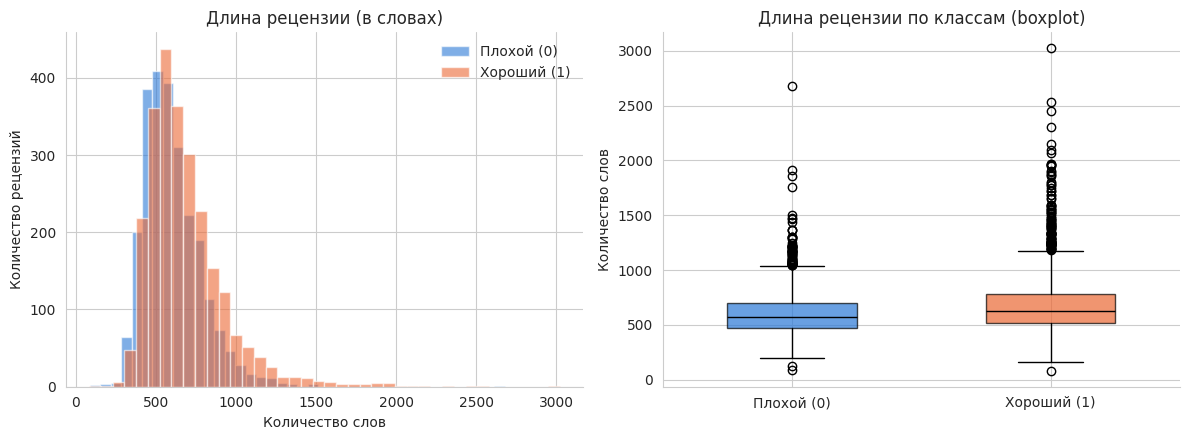

In [5]:
df['word_count'] = df['content'].str.split().str.len()

print(df['word_count'].describe())
print()
print("По классам:")
print(df.groupby('label')['word_count'].describe()[['mean', '50%', 'std']])

colors = {0: '#2a78d6', 1: '#eb6834'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# гистограмма
ax = axes[0]
for label, name in [(0, 'Плохой (0)'), (1, 'Хороший (1)')]:
    subset = df[df['label'] == label]['word_count']
    ax.hist(subset, bins=40, alpha=0.6, color=colors[label], label=name)
ax.set_title('Длина рецензии (в словах)')
ax.set_xlabel('Количество слов')
ax.set_ylabel('Количество рецензий')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# boxplot
ax = axes[1]
data_to_plot = [df[df['label'] == 0]['word_count'], df[df['label'] == 1]['word_count']]
bp = ax.boxplot(data_to_plot, tick_labels=['Плохой (0)', 'Хороший (1)'], patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], [colors[0], colors[1]]):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
ax.set_title('Длина рецензии по классам (boxplot)')
ax.set_ylabel('Количество слов')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Средний размер рецензии составляет около 646 слов, но разброс большой (от 84 до 3021 слов). "Хорошие" отзывы (label=1) в среднем длиннее "плохих" (687 слов против 604) - критики Pitchfork пишут более развёрнуто, когда альбом им понравился. Значит, длина текста сама по себе может быть полезным признаком для модели, а не только сам текст. На обоих boxplot видно много выбросов сверху - очень длинные рецензии на некоторые альбомы. Некоторые критики пишут небольшие эссе в отзывах.

In [6]:
import re
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

stop_words = set(STOPWORDS)

def clean_words(text):
    text = text.lower()
    words = re.findall(r"[a-z']+", text)
    return [w for w in words if w not in stop_words and len(w) > 2]

good_text = ' '.join(df[df['label'] == 1]['content'])
bad_text = ' '.join(df[df['label'] == 0]['content'])

good_words = clean_words(good_text)
bad_words = clean_words(bad_text)

print("Топ-15 слов в хороших отзывах:")
print(Counter(good_words).most_common(15))
print()
print("Топ-15 слов в плохих отзывах:")
print(Counter(bad_words).most_common(15))

Топ-15 слов в хороших отзывах:
[('music', 5656), ('one', 5615), ('album', 5455), ('songs', 3802), ('band', 3630), ('sound', 3522), ('song', 3358), ('even', 3289), ('new', 3050), ('time', 3006), ('first', 2690), ('record', 2669), ('guitar', 2668), ('two', 2571), ('rock', 2561)]

Топ-15 слов в плохих отзывах:
[('album', 5189), ('one', 4538), ('music', 3794), ('songs', 3736), ('band', 3470), ('even', 3215), ('song', 3170), ('sound', 3044), ('time', 2628), ('rock', 2627), ('new', 2622), ('much', 2524), ('pop', 2486), ('record', 2459), ('first', 2336)]


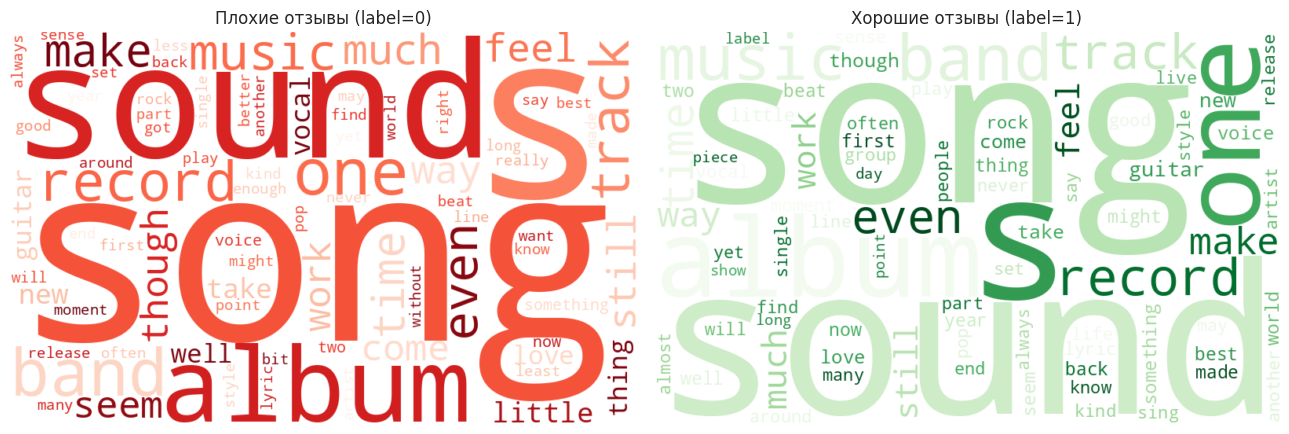

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

wc_bad = WordCloud(width=800, height=500, background_color='white',
                    stopwords=stop_words, colormap='Reds', max_words=80).generate(bad_text)
axes[0].imshow(wc_bad, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Плохие отзывы (label=0)')

wc_good = WordCloud(width=800, height=500, background_color='white',
                     stopwords=stop_words, colormap='Greens', max_words=80).generate(good_text)
axes[1].imshow(wc_good, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Хорошие отзывы (label=1)')

plt.tight_layout()
plt.show()

Топ-слова и облака слов у хороших и плохих отзывов почти совпадают (album, song, band, music и тд), т.е. по частотности отдельных слов классы плохо различимы. Значит, для моделей лучше использовать TF-IDF вместо простого подсчёта слов, потому что он снижает вес таких общих терминов и выделяет более редкие и характерные слова.

In [8]:
# проверка самых коротких и самых длинных рецензий на адеватность
print("5 самых коротких рецензий:")
print(df.nsmallest(5, 'word_count')[['artist', 'title', 'word_count']])
print()
print("5 самых длинных рецензий:")
print(df.nlargest(5, 'word_count')[['artist', 'title', 'word_count']])
print()

# поиск служебных символов переноса строки внутри текста
has_crlf = df['content'].str.contains(r'\r\n', regex=True).sum()
starts_with_ws = df['content'].str.match(r'^\s').sum()
print("Рецензий с \\r\\n внутри текста:", has_crlf)
print("Рецензий, начинающихся с пробельных символов:", starts_with_ws)
print()

# поиск выбросов IQR
q1, q3 = df['word_count'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df['word_count'] < lower) | (df['word_count'] > upper)]
print(f"Границы нормального диапазона (IQR): [{lower:.0f}, {upper:.0f}] слов")
print(f"Выбросов по длине текста: {len(outliers)} ({len(outliers)/len(df):.1%} от датасета)")

5 самых коротких рецензий:
              artist                   title  word_count
3737  chad vangaalen           soft airplane          84
4782  regina spektor     remember us to life          90
2310       styrofoam        a thousand words         128
429   ben folds five  whatever and ever amen         165
440           tennis        ritual in repeat         195

5 самых длинных рецензий:
                     artist                                          title  \
4073      throbbing gristle  the second annual report of throbbing gristle   
4651  red hot chili peppers                          blood sugar sex magik   
1505             nick drake                                       tuck box   
2931              brand new         the devil and god are raging inside me   
1710                 prince                                    controversy   

      word_count  
4073        3021  
4651        2678  
1505        2536  
2931        2453  
1710        2301  

Рецензий с \r\n внут

In [9]:
# чистим служебные \r\n и лишние пробелы по краям
df['content'] = df['content'].str.replace(r'\r\n', ' ', regex=True).str.strip()

print("Пример очищенного текста:")
print(df['content'].iloc[0][:150])

Пример очищенного текста:
Gang Gang Dance's 2006 CMJ performance at Webster Hall remains an unexpectedly transcendent moment. I'd seen the quartet a dozen times before (and in 


Как было выяснено выше, тексты сильно разнятся по длине (от 84 до 3021 слова), но это всего лишь естественный разброс в стиле критиков и согласно IQR выбросы по длине текста составляют всего 3.7% датасета, поэтому удалять их нет смысла. Однако было выявлено большое количество "технического мусора" - у 708 рецензий (14%) внутри текста находятся служебные символы \r\n, а у 395 есть лишние пробелы в начале. Поэтому была проведена чистка текста от этого "мусора".

In [10]:
import re
from wordcloud import STOPWORDS

stop_words = set(STOPWORDS)

# статистические признаки (длина текста, количество слов, количество предложений, средняя длина слова)
df['char_count'] = df['content'].str.len()
df['word_count'] = df['content'].str.split().str.len()
df['sentence_count'] = df['content'].apply(lambda t: len(re.findall(r'[.!?]+', t)))
df['avg_word_length'] = df['content'].apply(
    lambda t: sum(len(w) for w in t.split()) / max(len(t.split()), 1)
)

# лексические признаки
def unique_word_count(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    return len(set(words))

def lexical_diversity(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    return len(set(words)) / len(words) if words else 0

def stopword_count(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    return sum(1 for w in words if w in stop_words)

df['unique_words'] = df['content'].apply(unique_word_count)
df['lexical_diversity'] = df['content'].apply(lexical_diversity)
df['stopword_count'] = df['content'].apply(stopword_count)

feature_cols = ['char_count', 'word_count', 'sentence_count', 'avg_word_length',
                 'unique_words', 'lexical_diversity', 'stopword_count']

print("Статистика по всем признакам:")
print(df[feature_cols].describe())
print()
print("Среднее значение по классам:")
print(df.groupby('label')[feature_cols].mean().round(3).T)

Статистика по всем признакам:
         char_count  word_count  sentence_count  avg_word_length  \
count   5000.000000  5000.00000     5000.000000      5000.000000   
mean    4024.206200   645.80160       27.073800         5.140525   
std     1395.440537   227.96038       11.603675         0.223424   
min      479.000000    84.00000        3.000000         4.223228   
25%     3101.000000   497.00000       20.000000         4.986827   
50%     3738.000000   599.00000       25.000000         5.129947   
75%     4621.000000   742.00000       31.000000         5.279986   
max    18950.000000  3021.00000      133.000000         6.025522   

       unique_words  lexical_diversity  stopword_count  
count   5000.000000        5000.000000     5000.000000  
mean     380.370400           0.585396      285.205800  
std      101.701087           0.052990      107.535978  
min       64.000000           0.344156       38.000000  
25%      312.000000           0.550665      215.000000  
50%      363.00

Хорошие отзывы в среднем длиннее плохих по всем "объёмным" метрикам (символы, слова, предложения, уникальные слова), но по лексическому разнообразию классы почти не отличаются ((0.592 у плохих и 0.579 у хороших). Таким образом, для модели полезнее длина текста, а не разнообразие слов.

In [11]:
# синтаксические признаки
import string

df['punctuation_count'] = df['content'].apply(lambda t: sum(1 for ch in t if ch in string.punctuation))
df['uppercase_count'] = df['content'].apply(lambda t: sum(1 for ch in t if ch.isupper()))
df['digit_count'] = df['content'].apply(lambda t: sum(1 for ch in t if ch.isdigit()))

syn_cols = ['punctuation_count', 'uppercase_count', 'digit_count']
print(df[syn_cols].describe())
print()
print("Среднее по классам:")
print(df.groupby('label')[syn_cols].mean().round(2).T)

       punctuation_count  uppercase_count  digit_count
count         5000.00000      5000.000000  5000.000000
mean           139.47980       106.886200    11.789200
std             54.56421        46.549529    11.959806
min              9.00000         7.000000     0.000000
25%            102.00000        77.000000     4.000000
50%            129.00000        98.000000     9.000000
75%            164.00000       125.000000    16.000000
max            594.00000       604.000000   192.000000

Среднее по классам:
label                   0       1
punctuation_count  132.53  146.43
uppercase_count    101.33  112.44
digit_count         10.63   12.95


У хороших отзывов знаков препинания, заглавных букв и цифр больше, чем у плохих отзывов, но это просто следствие большей длины текста, т.е. самостоятельной новой информации эти признаки не добавляют.

In [12]:
# TF-IDF/CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# max_features=1000 - берём 1000 самых значимых слов
# stop_words='english' - убираем английские стоп-слова на этапе векторизации
# min_df=5 - игнорируем слова, встретившиеся меньше чем в 5 документах (опечатки, редкие имена)
# max_df=0.8 - игнорируем слова, встречающиеся более чем в 80% документов (слишком общие)

tfidf = TfidfVectorizer(max_features=1000, stop_words='english', min_df=5, max_df=0.8)
tfidf_matrix = tfidf.fit_transform(df['content'])
print("TF-IDF матрица:", tfidf_matrix.shape)
print("Пример слов из словаря:", tfidf.get_feature_names_out()[:15])
print()

count_vec = CountVectorizer(max_features=1000, stop_words='english', min_df=5, max_df=0.8)
count_matrix = count_vec.fit_transform(df['content'])
print("CountVectorizer матрица:", count_matrix.shape)

TF-IDF матрица: (5000, 1000)
Пример слов из словаря: ['10' '12' '20' '2003' '2004' '2006' '2009' '2010' '2011' '60s' '70s'
 '80s' '90s' 'ability' 'able']

CountVectorizer матрица: (5000, 1000)



В соттветствии с заданием обе матрицы получились 5000*1000. Ожидается, что TF-IDF даст лучшее качество моделей, чем CountVectorizer, так как снижает вес общих слов вроде album, song, band и т.д.

In [13]:
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

engineered_cols = ['char_count', 'word_count', 'sentence_count', 'avg_word_length', 'unique_words',
                    'lexical_diversity', 'stopword_count', 'punctuation_count', 'uppercase_count', 'digit_count']

X_engineered = df[engineered_cols].values
y = df['label'].values

X_combined = hstack([tfidf_matrix, csr_matrix(StandardScaler().fit_transform(X_engineered))])

def evaluate(X, name, scale=False):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    if scale:
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)
    model = LogisticRegression(max_iter=1000)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    print(f"{name}: accuracy = {acc:.3f}")
    return acc

print("Быстрое сравнение наборов признаков (Logistic Regression, train/test 80/20):")
acc_eng = evaluate(X_engineered, "Только статистические/лексические/синтаксические признаки", scale=True)
acc_count = evaluate(count_matrix, "Только CountVectorizer")
acc_tfidf = evaluate(tfidf_matrix, "Только TF-IDF")
acc_combined = evaluate(X_combined, "TF-IDF + engineered features")

Быстрое сравнение наборов признаков (Logistic Regression, train/test 80/20):
Только статистические/лексические/синтаксические признаки: accuracy = 0.574
Только CountVectorizer: accuracy = 0.655
Только TF-IDF: accuracy = 0.687
TF-IDF + engineered features: accuracy = 0.692


TF-IDF (accuracy 0.687) лучше, чем CountVectorizer (accuracy 0.655). Engineered-признаки сами по себе слабые (accuracy 0.574), но в дополнение к TF-IDF дают небольшой прирост (accuracy 0.692), поэтому в дальнейшем имеет смысл использовать связку TF-IDF + engineered-признаки.


По Части 1 можно сделать следующий вывод: датасет чистый и сбалансированный (2500/2500, дубликатов нет). Присутствовал "технический мусор", который был почищен. Хорошие отзывы длиннее плохих по всем "объемным" метрикам, но не отличаются по разнообразию слов. Отдельные слова слабо разделяют классы, поэтому в качестве текстовых признаков выбран TF-IDF, а не простой подсчёт слов. Был выбран итоговый набор признаков для обучения моделей: TF-IDF (1000 признаков) + 10 статистических/лексических/синтаксических признаков.

**Часть 2. Обучение и тюнинг моделей**

In [14]:
from sklearn.model_selection import train_test_split

X = X_combined               # X - уже готовая объединённая матрица TF-IDF + engineered-признаков
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Баланс классов в train:", np.bincount(y_train))
print("Баланс классов в test:", np.bincount(y_test))

X_train: (4000, 1010)
X_test: (1000, 1010)
Баланс классов в train: [2000 2000]
Баланс классов в test: [500 500]


In [15]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}

trained_models = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    acc = model.score(X_test, y_test)
    print(f"{name}: accuracy={acc:.3f}, время обучения={elapsed:.2f}с")
    trained_models[name] = model

Logistic Regression: accuracy=0.692, время обучения=0.30с
KNN: accuracy=0.558, время обучения=0.00с
Decision Tree: accuracy=0.596, время обучения=2.61с
Random Forest: accuracy=0.636, время обучения=8.85с
XGBoost: accuracy=0.647, время обучения=30.49с


Лучшей оказалась модель Logistic Regression (accuracy 0.692). Хуже всех справились Decision Tree и KNN (accuracy 0.596 и 0.558 соответственоо), возможно они хуже работают с разреженной TF-IDF-матрицей (1010 признаков), в отличие от линейной модели.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []
predictions = {}

for name, model in trained_models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.round(3)

,Модель,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.692,0.696,0.682,0.689
1,XGBoost,0.647,0.643,0.660,0.652
2,Random Forest,0.636,0.657,0.570,0.610
3,Decision Tree,0.596,0.594,0.608,0.601
4,KNN,0.558,0.558,0.554,0.556


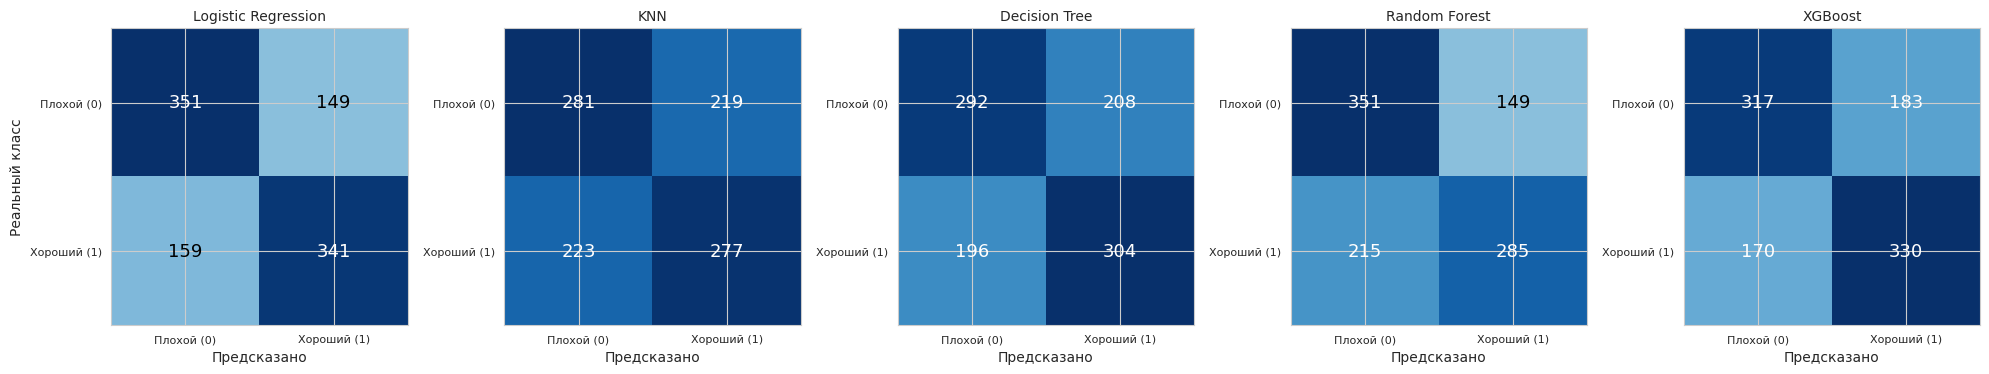

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
model_order = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost']

for ax, name in zip(axes, model_order):
    cm = confusion_matrix(y_test, predictions[name])
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=13)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Плохой (0)', 'Хороший (1)'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Плохой (0)', 'Хороший (1)'], fontsize=8)
    ax.set_xlabel('Предсказано')
    if name == model_order[0]:
        ax.set_ylabel('Реальный класс')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

Logistic Regression лидирует по всем метрикам сразу. Random Forest и XGBoost показывали средний результат, а Decision Tree и KNN путают почти половину примеров, т.е. их предсказания близки к случайным. Поэтому для тюнинга будут использованы Logistic Regression, XGBoost, Random Forest.

In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

tuned_results = []

# Logistic Regression
lr_grid = {'C': [0.01, 0.1, 1, 10]}
lr_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_grid, cv=3, scoring='f1', n_jobs=-1)
lr_search.fit(X_train, y_train)
lr_test_f1 = f1_score(y_test, lr_search.predict(X_test))
print(f"Logistic Regression: лучшие параметры {lr_search.best_params_}, F1 на тесте = {lr_test_f1:.3f}")
tuned_results.append({'Модель': 'Logistic Regression', 'F1 до тюнинга': 0.689, 'F1 после тюнинга': lr_test_f1, 'Лучшие параметры': lr_search.best_params_})

# Random Forest
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_grid, n_iter=10, cv=3,
                                scoring='f1', n_jobs=-1, random_state=42)
rf_search.fit(X_train, y_train)
rf_test_f1 = f1_score(y_test, rf_search.predict(X_test))
print(f"Random Forest: лучшие параметры {rf_search.best_params_}, F1 на тесте = {rf_test_f1:.3f}")
tuned_results.append({'Модель': 'Random Forest', 'F1 до тюнинга': 0.611, 'F1 после тюнинга': rf_test_f1, 'Лучшие параметры': rf_search.best_params_})

# XGBoost
xgb_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.85, 1.0],
}
xgb_search = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_grid, n_iter=8, cv=3,
                                 scoring='f1', n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)
xgb_test_f1 = f1_score(y_test, xgb_search.predict(X_test))
print(f"XGBoost: лучшие параметры {xgb_search.best_params_}, F1 на тесте = {xgb_test_f1:.3f}")
tuned_results.append({'Модель': 'XGBoost', 'F1 до тюнинга': 0.656, 'F1 после тюнинга': xgb_test_f1, 'Лучшие параметры': xgb_search.best_params_})

tuned_df = pd.DataFrame(tuned_results)
tuned_df.round(3)

Logistic Regression: лучшие параметры {'C': 1}, F1 на тесте = 0.689
Random Forest: лучшие параметры {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 30}, F1 на тесте = 0.644
XGBoost: лучшие параметры {'subsample': 0.85, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}, F1 на тесте = 0.661


,Модель,F1 до тюнинга,F1 после тюнинга,Лучшие параметры
0,Logistic Regression,0.689,0.689,{'C': 1}
1,Random Forest,0.611,0.644,"{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 30}"
2,XGBoost,0.656,0.661,"{'subsample': 0.85, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}"


Хотя после тюнинга F1 вырос для Random Forest	и XGBoost, значение для Logistic Regression все равно выше, поэтому дальше она будет использована как рабочая.

In [19]:
import joblib

scaler = StandardScaler()
scaler.fit(df[engineered_cols])

# сохраняем модель + TF-IDF векторизатор + scaler
joblib.dump(lr_search.best_estimator_, 'model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print("Модель и препроцессоры сохранены")

Модель и препроцессоры сохранены


In [20]:
best_model = lr_search.best_estimator_

# имена всех 1010 признаков: 1000 слов из TF-IDF + 10 engineered-признаков
feature_names = list(tfidf.get_feature_names_out()) + engineered_cols
coefs = best_model.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
top_positive = coef_df.sort_values('coef', ascending=False).head(15)
top_negative = coef_df.sort_values('coef').head(15)

print("Топ-15 признаков ЗА 'хороший' отзыв:")
print(top_positive.to_string(index=False))
print()
print("Топ-15 признаков ЗА 'плохой' отзыв:")
print(top_negative.to_string(index=False))
print()

eng_coefs = coef_df[coef_df['feature'].isin(engineered_cols)].sort_values('coef', ascending=False)
print("Engineered-признаки:")
print(eng_coefs.to_string(index=False))

Топ-15 признаков ЗА 'хороший' отзыв:
  feature     coef
   simple 2.360320
    music 1.671704
   subtle 1.638362
    drone 1.465324
  classic 1.410804
    final 1.407667
     funk 1.405961
    story 1.395432
excellent 1.342846
 gorgeous 1.326910
    notes 1.310982
  strings 1.302957
  complex 1.296608
  melodic 1.296338
    scene 1.275424

Топ-15 признаков ЗА 'плохой' отзыв:
      feature      coef
unfortunately -3.885536
      problem -3.365747
       better -2.535177
  interesting -2.226955
       little -2.191625
         lack -2.096485
         said -2.042978
   ultimately -1.918514
          bad -1.868071
        doesn -1.753362
      remixes -1.614687
        worst -1.602745
        worse -1.569198
       pretty -1.564103
         best -1.516651

Engineered-признаки:
          feature      coef
       word_count  0.453102
       char_count  0.369579
punctuation_count  0.220911
     unique_words  0.108441
  avg_word_length -0.046272
      digit_count -0.072250
lexical_diversity -0

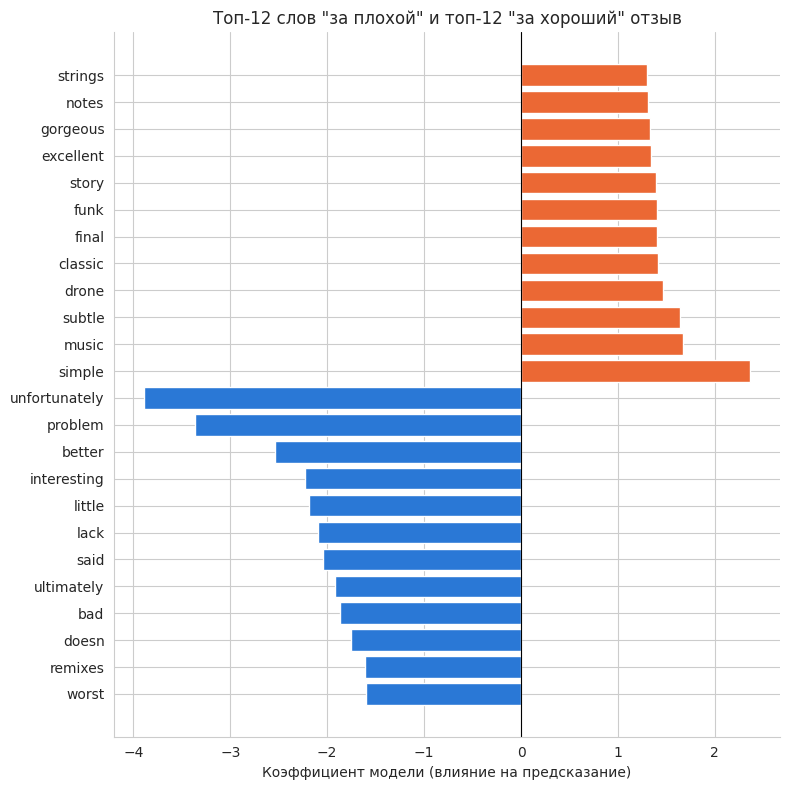

In [21]:
top_pos = coef_df.sort_values('coef', ascending=False).head(12)
top_neg = coef_df.sort_values('coef').head(12)
plot_df = pd.concat([top_neg.iloc[::-1], top_pos]).reset_index(drop=True)

colors = ['#2a78d6' if c < 0 else '#eb6834' for c in plot_df['coef']]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(plot_df['feature'], plot_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Коэффициент модели (влияние на предсказание)')
ax.set_title('Топ-12 слов "за плохой" и топ-12 "за хороший" отзыв')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np

idx = np.arange(len(df))
_, _, _, _, idx_train, idx_test = train_test_split(X, y, idx, test_size=0.2, random_state=42, stratify=y)

pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

test_df = df.iloc[idx_test].copy().reset_index(drop=True)
test_df['true_label'] = y_test
test_df['pred_label'] = pred
test_df['proba_good'] = proba

correct = test_df[test_df['true_label'] == test_df['pred_label']]
incorrect = test_df[test_df['true_label'] != test_df['pred_label']]

print(f"Верных предсказаний: {len(correct)}, ошибочных: {len(incorrect)}")

print("\n=== 2 примера ВЕРНЫХ предсказаний (модель уверена) ===")
conf_correct = correct.reindex(correct['proba_good'].sub(0.5).abs().sort_values(ascending=False).index).head(2)
for _, row in conf_correct.iterrows():
    print(f"\n{row['artist']} - {row['title']} | реальный: {row['true_label']}, предсказано: {row['pred_label']}, P(хороший)={row['proba_good']:.2f}")
    print(row['content'][:200])

print("\n=== 2 примера ОШИБОЧНЫХ предсказаний ===")
conf_incorrect = incorrect.reindex(incorrect['proba_good'].sub(0.5).abs().sort_values(ascending=False).index).head(2)
for _, row in conf_incorrect.iterrows():
    print(f"\n{row['artist']} - {row['title']} | реальный: {row['true_label']}, предсказано: {row['pred_label']}, P(хороший)={row['proba_good']:.2f}")
    print(row['content'][:200])

Верных предсказаний: 692, ошибочных: 308

=== 2 примера ВЕРНЫХ предсказаний (модель уверена) ===

various artists - the rise & fall of paramount records, volume one (1917-1932) | реальный: 1, предсказано: 1, P(хороший)=0.98
The Rise and Fall of Paramount Records: Vol. 1 (1917–1932) arrives like a family of nested matryoshka dolls. Sent by post, the 22-pound compendium comes in a wide and thick cardboard box, with the nam

jd twitch - mx6: twitch's 60 minutes of fear | реальный: 1, предсказано: 1, P(хороший)=0.98
The first radio personality to earn the tag "disk jockey" didn't just play records-- he wove an elaborate illusion. Whether newsman Walter Winchell was talking about horse racers or machine operators 

=== 2 примера ОШИБОЧНЫХ предсказаний ===

sarah cracknell - lipslide | реальный: 1, предсказано: 0, P(хороший)=0.06
Cotton candy textures. Lollipop melodies. A wafer thin voice. We're talking about Britney
    Spears' Oops!... I Did It Again, right? Nay, it's that British bombshe

Модель опирается на осмысленную лексику, а не на шум - это подтверждает, что весь пайплайн работает правильно. Главная слабость - ирония и сарказм, характерная для профессиональных обзоров.
Самые значимые признаки - конкретные оценочные слова: за "хороший" отзыв сильнее всего говорят excellent, gorgeous, subtle, classic, melodic, за "плохой" - unfortunately, problem, lack, bad, worst. Из инженерных признаков заметнее всего влияют word_count и char_count (длина текста - положительно) и stopword_count (отрицательно).